In [1]:
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Load in Data

* Range of data: 1/1/2022 to 3/22/2024
* Train/validation range: 1/1/2022 to 1/14/2023
    * 0.8/0.2 random train-validation split
* Test range: 1/15/2024-3/22/2024

In [2]:
data = pd.read_csv("data.csv")

In [3]:
train = data.loc[:71423]
train.head(3)

,Unnamed: 0,date,time,power,workday
0,0,2022-01-01,0.00,0.0,0
1,1,2022-01-01,0.25,0.0,0
2,2,2022-01-01,0.50,0.0,0


In [4]:
test = data.loc[71424:]
test.head(3)

,Unnamed: 0,date,time,power,workday
71424,71424,2024-01-15,0.00,-1.367699e-07,0
71425,71425,2024-01-15,0.25,-1.367699e-07,0
71426,71426,2024-01-15,0.50,-1.367699e-07,0


In [5]:
def get_X_y(df, lookahead):
    power = df['power'].to_numpy()
    workday = df['workday'].to_numpy()
    time = df['time'].to_numpy()
    
    power_chunks = [power[i:i+lookahead] for i in range(0, len(power) - lookahead, lookahead)]
    workday = [workday[i] for i in range(0, len(power) - lookahead, lookahead)]
    time = [time[i] for i in range(0, len(power) - lookahead, lookahead)]
    
    y = [power[i:i+lookahead] for i in range(lookahead, len(power), lookahead)]

    X = pd.DataFrame(data={"power" : power_chunks, "workday" : workday, "time" : time})
    y = pd.DataFrame(data={"power" : y})

    X = X.reset_index()
    y = y.reset_index()

    return X, y

In [6]:
LOOKAHEAD = 16

X_trainval, y_trainval = get_X_y(train, LOOKAHEAD)
X_test, y_test = get_X_y(test, LOOKAHEAD)

# Tuning K with Validation Set

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

mses = []
wmses = []

alpha = 0.2

for k in range(1, 21):
    models = {}
    for t in [0, 4, 8, 12, 16, 20]:
        for w in [0, 1]:
            knn_regressor = KNeighborsRegressor(n_neighbors=k, weights='distance')
            mask = (X_train['time'] == t) & (X_train['workday'] == w)
            X_input = X_train[mask]['power']  
            y_input = y_train[mask]['power']  
            X_input = np.array([i for i in X_input])
            y_input = np.array([i for i in y_input])
            knn_regressor.fit(X_input, y_input)
            models[(t, w)] = knn_regressor


    forecasts = []
    for index, row in X_val.iterrows():
        forecasts.append(models[(row['time'], row['workday'])].predict(np.array(row['power']).reshape(1, -1)))

    forecast = np.array([f[0] for f in forecasts]).flatten()
    real = np.array([a for a in y_val['power'].to_numpy()]).flatten()

    mse = mean_squared_error(forecast, real)

    weights = alpha ** (1 + np.sign(forecast - real))
    wmse = mean_squared_error(forecast, real, sample_weight=weights)

    mses.append(mse)
    wmses.append(wmse)
    
    print(f"k={k}\tMSE={mse}\tWMSE={wmse}")

k=1	MSE=28.68427413777048	WMSE=34.28171901908787
k=2	MSE=22.32241878745913	WMSE=28.481318440955256
k=3	MSE=19.073685993578056	WMSE=26.255922346417556
k=4	MSE=18.399869019932854	WMSE=26.677896085236895
k=5	MSE=18.367259010216674	WMSE=27.47192459734201
k=6	MSE=17.897573329478607	WMSE=27.790381827270203
k=7	MSE=17.907842216793792	WMSE=27.91143437154087
k=8	MSE=17.888954144607798	WMSE=28.593756717705812
k=9	MSE=17.795255386238225	WMSE=29.029844281308442
k=10	MSE=17.826078329929352	WMSE=29.63326450684148
k=11	MSE=17.690811262953847	WMSE=29.836827809091943
k=12	MSE=17.738857923337548	WMSE=29.908214870530223
k=13	MSE=17.847471175730398	WMSE=30.141923586597592
k=14	MSE=17.82407530421847	WMSE=30.595878164327832
k=15	MSE=17.816552793983476	WMSE=30.818069312695656
k=16	MSE=17.90934753157062	WMSE=30.986158027861794
k=17	MSE=17.89312771981891	WMSE=31.183063976881765
k=18	MSE=17.93418728801791	WMSE=31.29665171851349
k=19	MSE=17.964098072351632	WMSE=31.5151227002784
k=20	MSE=18.04341418906108	WMSE=31

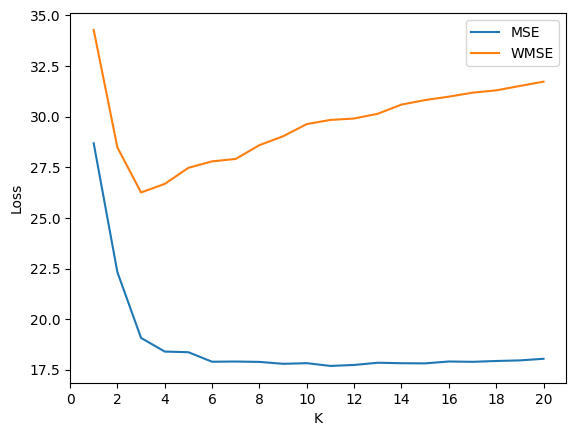

In [9]:
plt.plot(range(1, 21), mses, label="MSE")
plt.plot(range(1, 21), wmses, label="WMSE")
plt.legend()
plt.xlabel("K")
plt.xticks(range(0, 21, 2))
plt.ylabel("Loss");

# Final Model
* k = 3
* Train with all data between 1/1/2022 and 1/14/2024
* Test with data between 1/15/2024 and 3/22/2024

In [10]:
models = {}


for t in [0, 4, 8, 12, 16, 20]:
    for w in [0, 1]:
        knn_regressor = KNeighborsRegressor(n_neighbors=4, weights='distance')
        mask = (X_trainval['time'] == t) & (X_trainval['workday'] == w)
        X_input = X_trainval[mask]['power']  
        y_input = y_trainval[mask]['power']  
        X_input = np.array([i for i in X_input])
        y_input = np.array([i for i in y_input])
        knn_regressor.fit(X_input, y_input)
        models[(t, w)] = knn_regressor

In [11]:
forecasts = []
for index, row in X_test.iterrows():
    forecasts.append(models[(row['time'], row['workday'])].predict(np.array(row['power']).reshape(1, -1)))

forecast = np.array([f[0] for f in forecasts]).flatten()
real = np.array([a for a in y_test['power'].to_numpy()]).flatten()

mse = mean_squared_error(forecast, real)

weights = alpha ** (1 + np.sign(forecast - real))
wmse = mean_squared_error(forecast, real, sample_weight=weights)

print(f"MSE={mse}\tWMSE={wmse}")

MSE=26.90712038208708	WMSE=42.83339884157188


# Sanity Check

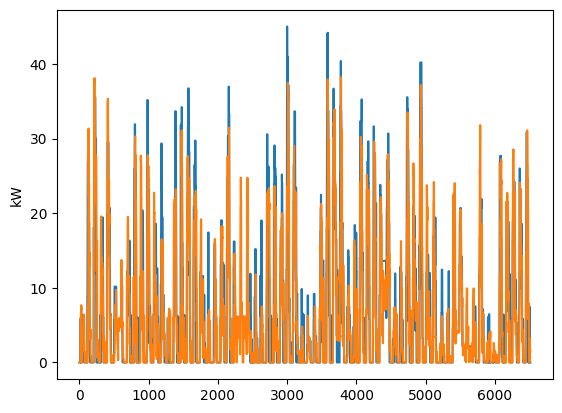

In [12]:
all_forecast = np.array([f[0] for f in forecasts]).flatten()
all_real = np.array([a for a in y_test['power'].to_numpy()]).flatten()

plt.plot(real, label="Actual")
plt.plot(forecast, label="Forecast")
plt.ylabel("kW");